# 03. Fair Representation Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Assess representation and inclusion in data and design
- Address underrepresentation and stereotyping
- Promote equitable outcomes across groups

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 2, lesson 02 "Missing Values & Duplicates" — who is missing from a dataset is a data-quality question and a fairness question at the same time.

---


# 03. Fair Representation Learning

## 🚨 THE PROBLEM: Data Doesn't Represent Groups Fairly

**Remember the limitation from the previous notebook?**

We learned how to mitigate bias using pre-processing, in-processing, and post-processing techniques. But we discovered:

**What if the data itself doesn't represent groups fairly?**

**The Problem**: Even with mitigation techniques, if the data doesn't represent groups fairly:
- Mitigation techniques may not work effectively
- We can't fix what's not in the data
- Underrepresented groups may still be disadvantaged
- Historical biases persist in the data

**We've learned:**
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ That data representation matters

**But we haven't learned:**
- ❌ How to **ensure fair representation** in data
- ❌ How to **remove bias from features** themselves
- ❌ How to **transform features** to be fair

**We need fair representation techniques** to:
1. Remove bias from feature representations
2. Ensure all groups are fairly represented in the data
3. Transform features to remove sensitive information
4. Create fair datasets from the start

**This notebook solves that problem** by teaching you fair representation learning techniques like PCA, autoencoders, and adversarial debiasing!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - Understanding how to detect bias
- ✅ **Example 2: Bias Mitigation** - Understanding mitigation techniques
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts
- ✅ **Understanding of neural networks**: Autoencoders, PCA (helpful but not required)

**If you haven't completed these**, you might struggle with:
- Understanding why fair representation matters
- Knowing how to remove bias from feature representations
- Understanding different fair representation techniques

---

## 🔗 Where This Notebook Fits

**This is the THIRD example in Unit 2** - it teaches you how to ensure fair representation in your data!

**Why this example THIRD?**
- **Before** you can ensure fair representation, you need to detect bias (Example 1)
- **Before** you can learn fair representation, you need to understand mitigation (Example 2)
- **Before** you can build fair systems, you need fair representation techniques

**Builds on**: 
- 📓 Example 1: Bias Detection (we detected bias)
- 📓 Example 2: Bias Mitigation (we learned to fix bias)

**Leads to**: 
- 📓 Example 4: Bias Case Studies (analyzing real bias cases)
- 📓 Example 5: Fair AI Development (building fair AI systems)

**Why this order?**
1. Fair representation provides **data-level solutions** (complements mitigation)
2. Fair representation teaches **feature transformation** (critical skill)
3. Fair representation shows **advanced techniques** (PCA, autoencoders, adversarial)

---

## The Story: Fair Features for Fair Models

Imagine you're a chef preparing ingredients. **Before** cooking, you need to prepare ingredients properly - wash vegetables, remove spoiled parts, cut uniformly. **After** preparation, you have clean, uniform ingredients that make better dishes!

Same with AI: **Before** we have features that may contain bias, now we transform them to remove bias - use PCA, autoencoders, or adversarial techniques. **After** fair representation, we have features that don't encode bias!

---

## Why Fair Representation Matters

Fair representation is essential for ethical AI:
- **Remove Bias from Features**: Transform features to remove sensitive information
- **Better Generalization**: Fair features lead to more generalizable models
- **Privacy Protection**: Remove sensitive information from representations
- **Compliance**: Meet fairness requirements at the data level
- **Foundation for Fairness**: Fair representation is the foundation for fair models

## Learning Objectives
1. Understand what fair representation means
2. Learn PCA for bias removal
3. Learn autoencoders for feature transformation
4. Learn adversarial debiasing techniques
5. Compare effectiveness of different fair representation methods
6. Understand when to use each technique

## 📌 The case: Amazon deleted the gendered words, and it did not help

Reuters (Jeffrey Dastin) reported in **October 2018** that Amazon had built an experimental
résumé-screening engine and then abandoned it. The engine had been trained on the company's
own historical hiring record — a record dominated by men — and it had learned to reproduce
it. It **downgraded résumés containing the word "women's"** (as in "women's chess club
captain") and penalised graduates of two all-women colleges.

Then comes the part that this notebook is about. Amazon's engineers **edited the programs to
be neutral to those particular terms**. That is fairness-through-unawareness applied to
features, and it is exactly what a naive representation transform does. It was not enough:
the company could not guarantee the model would not devise **other ways of sorting
candidates that amounted to the same thing**, and the project was shut down rather than
shipped.

That is the whole lesson in one sentence. *Deleting the signal you can name does not remove
the signal.* Notebook 02 already showed you the machine version: `CorrelationRemover`
guaranteed zero **linear** correlation with sex, and a random forest still recovered the
group with **100 % accuracy**. In this notebook you go looking for the leak yourself, with
an adversary — because the only honest way to know what a representation still carries is to
attack it.

**The WHY — what goes wrong without this.** Teams ship "de-biased" features constantly, on
the strength of a correlation matrix that shows nothing. Amazon at least had the discipline
to keep testing and kill the project. Without an adversary test you get the opposite
outcome: a system that is *documented* as neutral, sorting people by the attribute you
believed you had removed, with the documentation now standing between the affected person
and any remedy.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../../Course 04/datasets/raw/titanic.csv` - the same real manifest used in
  Notebooks 01-02. Here the protected attribute `Sex` is **held out of the feature
  matrix entirely**, so we can measure how much of it the remaining features leak.

**Outputs:** What you'll see when you run the cells

- The measured correlation between each real feature and the protected attribute
- PCA and autoencoder representations, scored on leakage *and* task accuracy
- Two adversaries (linear and non-linear) trying to recover the protected
  attribute from each representation, scored against the majority baseline

---

In [1]:
# Step 1: Import necessary libraries
# These libraries help us implement fair representation learning techniques

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split, cross_val_score  # For splitting data and scoring adversaries
from sklearn.decomposition import PCA  # For dimensionality reduction: Principal Component Analysis
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.metrics import accuracy_score  # For model evaluation: Accuracy metric
from sklearn.neural_network import MLPRegressor  # For neural networks: Autoencoder implementation
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (neural networks may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print(" Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (PCA, models, metrics, preprocessing)")
print("   - sklearn.neural_network: Neural networks (autoencoders)")
print("   - os: File operations (saving images)")

 Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (PCA, models, metrics, preprocessing)
   - sklearn.neural_network: Neural networks (autoencoders)
   - os: File operations (saving images)


## Part 2: Understanding Fair Representation

### 📚 Prerequisites (What You Need First)
- **Library imports** (from Part 1) - Understanding ML and neural network tools
- **Understanding of bias** (from Examples 1-2) - Knowing what bias looks like

### 🔗 Relationship: What This Builds On
This builds on bias detection and mitigation - we now ask whether the *features
themselves* still carry the protected attribute.
- Builds on: Bias detection skills, understanding of mitigation
- Shows: How to transform features, and how to verify the transformation worked

### 📖 The Story
**Before fair representation**: We deleted the `Sex` column and assumed the group
was gone. Notebook 01 already showed that assumption failing.
**After fair representation**: We can *measure* how much sensitive information a
set of features carries - and we will find that compression alone does not remove it.

In [2]:
# Step 2: Load the REAL Titanic manifest and MEASURE which real features
# leak the protected attribute. We do not invent proxies - we find them.

print("\n" + "="*80)
print("📊 REAL DATA: WHICH FEATURES LEAK GROUP MEMBERSHIP?")
print("="*80)

df = pd.read_csv('../../../Course 04/datasets/raw/titanic.csv')
# Same honest imputation as Notebooks 01-02, so all three are comparable.
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# The sensitive attribute is held OUT of the feature matrix on purpose: we want
# to know how much of it the remaining, "innocent" features give away.
sensitive_series = (df['Sex'] == 'female').astype(int)
feature_frame = pd.get_dummies(
    df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']],
    columns=['Embarked'], drop_first=True).astype(float)

df_rep = feature_frame.copy()
df_rep['sensitive'] = sensitive_series
df_rep['target'] = df['Survived']
FEATURES = list(feature_frame.columns)

print(f"Loaded {len(df_rep)} real passengers")
print(f"Features (sex deliberately EXCLUDED): {FEATURES}")
print(f"Group balance: female {sensitive_series.mean():.1%}, "
      f"male {1 - sensitive_series.mean():.1%}")

print("\nMeasured correlation of each REAL feature with the sensitive attribute:")
corrs = {}
for col in FEATURES:
    corrs[col] = np.corrcoef(df_rep[col], df_rep['sensitive'])[0, 1]
    print(f"  {col:<14}: {corrs[col]:+.3f}")

strongest = max(corrs, key=lambda c: abs(corrs[c]))
print(f"\nStrongest single proxy: {strongest} ({corrs[strongest]:+.3f})")
print("Note how MODEST these numbers are. Real proxies are rarely dramatic on")
print("their own - the danger is that many weak proxies COMBINE. The adversary")
print("test below measures the combined leak, which is the number that matters.")


📊 REAL DATA: WHICH FEATURES LEAK GROUP MEMBERSHIP?
Loaded 891 real passengers
Features (sex deliberately EXCLUDED): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Group balance: female 35.2%, male 64.8%

Measured correlation of each REAL feature with the sensitive attribute:
  Pclass        : -0.132
  Age           : -0.081
  SibSp         : +0.115
  Parch         : +0.245
  Fare          : +0.182
  Embarked_Q    : +0.074
  Embarked_S    : -0.119

Strongest single proxy: Parch (+0.245)
Note how MODEST these numbers are. Real proxies are rarely dramatic on
their own - the danger is that many weak proxies COMBINE. The adversary
test below measures the combined leak, which is the number that matters.


## Part 3: Three Fair Representation Techniques

1. **PCA**: project features onto principal components; check how much sensitive
   correlation survives in the new space.
2. **Autoencoder** (a small MLP trained to reconstruct its input): use the learned
   compressed representation as new features.
3. **Adversarial debiasing** (simplified): train an *adversary* to predict the sensitive
   attribute from the features - if the adversary succeeds, the features still leak
   sensitive information. (Full adversarial training alternates model vs adversary;
   here we only demonstrate the adversary-as-a-leak-detector idea.)

We run the adversary in **two strengths** - linear and non-linear. Notebook 02
showed why that matters: a representation can defeat a linear attacker completely
while a tree recovers the group perfectly.

In [3]:
# Why: fair representation learning transforms the FEATURES so they stop
# encoding group membership - then any downstream model is starved of the bias signal.

# Step 3: Define the fair representation techniques
from sklearn.linear_model import LogisticRegression  # adversary model

def fair_representation_pca(X, sensitive, n_components=2):
    """Project onto principal components; measure leftover sensitive correlation."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    pca = PCA(n_components=n_components)
    X_transformed = pca.fit_transform(X_scaled)
    correlations = [abs(np.corrcoef(X_transformed[:, i], sensitive)[0, 1])
                    for i in range(n_components)]
    return X_transformed, correlations, pca, scaler

def train_autoencoder(X, encoding_dim=2):
    """Train a small MLP autoencoder (encoder + decoder) with sklearn."""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    encoder = MLPRegressor(hidden_layer_sizes=(X.shape[1], encoding_dim),
                           activation='relu', solver='adam', max_iter=500,
                           random_state=42)
    encoder.fit(X_scaled, X_scaled)          # learn to reconstruct input
    # sklearn's MLP does not expose hidden activations, so we approximate the
    # 2-dim bottleneck code: take the network's reconstruction (which had to
    # pass through the small hidden layer) and compress it to encoding_dim
    # with PCA. The result reflects what survived the bottleneck.
    recon = encoder.predict(X_scaled)
    pca = PCA(n_components=encoding_dim)
    encoded = pca.fit_transform(recon)
    return encoder, scaler, pca, encoded

def evaluate_fairness(X_transformed, sensitive, method_name):
    """How much sensitive-attribute correlation survives the transformation?"""
    correlations = [abs(np.corrcoef(X_transformed[:, i], sensitive)[0, 1])
                    for i in range(X_transformed.shape[1])]
    avg_c, max_c = np.mean(correlations), np.max(correlations)
    print(f"\n{method_name}:")
    print(f"  Average correlation with sensitive attribute: {avg_c:.4f}")
    print(f"  Maximum correlation: {max_c:.4f}")
    return avg_c, max_c

def adversarial_leak_test(X, sensitive, nonlinear=False):
    """Adversary tries to predict the sensitive attribute from features.

    Compare the score against the MAJORITY baseline (the share of the larger
    group), not against 0.5 - the Titanic groups are not 50/50, so an
    adversary that always guessed "male" would already score ~0.65.
    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(np.asarray(X))
    if nonlinear:
        adversary = RandomForestClassifier(n_estimators=100, random_state=42)
    else:
        adversary = LogisticRegression(random_state=42, max_iter=1000)
    # Cross-validated so we score the adversary's ability to GENERALISE,
    # not its ability to memorise the rows it was shown.
    return cross_val_score(adversary, X_scaled, sensitive, cv=5).mean()

MAJORITY_BASELINE = max(df_rep['sensitive'].mean(), 1 - df_rep['sensitive'].mean())
print("Fair representation functions defined (PCA, autoencoder, adversary test).")
print(f"Majority baseline an adversary must beat to have learned anything: "
      f"{MAJORITY_BASELINE:.3f}")

Fair representation functions defined (PCA, autoencoder, adversary test).
Majority baseline an adversary must beat to have learned anything: 0.648


In [4]:
# Why compare: each representation trades some task signal for less group leakage -
# we measure both (accuracy + adversary accuracy) to see the trade-off honestly.

# Step 4: Compare original features vs PCA vs autoencoder representations

X = df_rep[FEATURES].values
y = df_rep['target'].values
sensitive = df_rep['sensitive'].values
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X, y, sensitive, test_size=0.3, random_state=42, stratify=y)
print(f"Train: {len(y_train)} passengers | Test: {len(y_test)} passengers")

results = {}

# 1. Baseline: original features
print("\n" + "="*80); print("1. BASELINE: Original Features"); print("="*80)
corr_orig = [abs(np.corrcoef(X_train[:, i], sensitive_train)[0, 1])
             for i in range(X_train.shape[1])]
print(f"Average correlation with sensitive attribute: {np.mean(corr_orig):.4f}")
scaler_orig = StandardScaler()
X_train_s = scaler_orig.fit_transform(X_train)
X_test_s = scaler_orig.transform(X_test)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_s, y_train)
acc = accuracy_score(y_test, model.predict(X_test_s))
print(f"Survival-prediction accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_train, sensitive_train)
adv_nl = adversarial_leak_test(X_train, sensitive_train, nonlinear=True)
print(f"Adversary accuracy - linear:     {adv_acc:.4f}")
print(f"Adversary accuracy - non-linear: {adv_nl:.4f}   "
      f"(majority baseline {MAJORITY_BASELINE:.3f})")
results['Original'] = {'correlation': np.mean(corr_orig), 'accuracy': acc,
                       'adversary': adv_acc, 'adversary_nl': adv_nl,
                       'features': X_train_s}

# 2. PCA-based representation
print("\n" + "="*80); print("2. PCA-BASED FAIR REPRESENTATION"); print("="*80)
X_pca, _, pca, scaler_pca = fair_representation_pca(X_train, sensitive_train, 2)
avg_corr, _ = evaluate_fairness(X_pca, sensitive_train, "PCA")
X_test_pca = pca.transform(scaler_pca.transform(X_test))
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_pca, y_train)
acc = accuracy_score(y_test, model.predict(X_test_pca))
print(f"Survival-prediction accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_pca, sensitive_train)
adv_nl = adversarial_leak_test(X_pca, sensitive_train, nonlinear=True)
print(f"Adversary accuracy - linear:     {adv_acc:.4f}")
print(f"Adversary accuracy - non-linear: {adv_nl:.4f}")
results['PCA'] = {'correlation': avg_corr, 'accuracy': acc,
                  'adversary': adv_acc, 'adversary_nl': adv_nl, 'features': X_pca}

# 3. Autoencoder-based representation
print("\n" + "="*80); print("3. AUTOENCODER-BASED FAIR REPRESENTATION"); print("="*80)
encoder, scaler_ae, pca_ae, X_encoded = train_autoencoder(X_train, encoding_dim=2)
avg_corr, _ = evaluate_fairness(X_encoded, sensitive_train, "Autoencoder")
X_test_encoded = pca_ae.transform(encoder.predict(scaler_ae.transform(X_test)))
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_encoded, y_train)
acc = accuracy_score(y_test, model.predict(X_test_encoded))
print(f"Survival-prediction accuracy: {acc:.4f}")
adv_acc = adversarial_leak_test(X_encoded, sensitive_train)
adv_nl = adversarial_leak_test(X_encoded, sensitive_train, nonlinear=True)
print(f"Adversary accuracy - linear:     {adv_acc:.4f}")
print(f"Adversary accuracy - non-linear: {adv_nl:.4f}")
results['Autoencoder'] = {'correlation': avg_corr, 'accuracy': acc,
                          'adversary': adv_acc, 'adversary_nl': adv_nl,
                          'features': X_encoded}

print("\n" + "="*80)
print(f"{'Representation':<16}{'Avg |corr|':>12}{'Task acc':>11}"
      f"{'Adv (lin)':>11}{'Adv (RF)':>11}")
print("-" * 80)
for name, r in results.items():
    print(f"{name:<16}{r['correlation']:>12.4f}{r['accuracy']:>11.4f}"
          f"{r['adversary']:>11.4f}{r['adversary_nl']:>11.4f}")
print(f"{'(baseline)':<16}{'-':>12}{'-':>11}"
      f"{MAJORITY_BASELINE:>11.3f}{MAJORITY_BASELINE:>11.3f}")

print("\nNOTE: neither PCA nor a plain autoencoder is TARGETED at the sensitive")
print("attribute - they compress whatever variance is largest, which is not the")
print("same as removing group information. The adversary columns above measure")
print("exactly how much survived. Targeted methods (fairlearn's CorrelationRemover")
print("from Notebook 02, or true adversarial training) attack the leak directly -")
print("and Notebook 02 showed even those come with a guarantee you must test.")

Train: 623 passengers | Test: 268 passengers

1. BASELINE: Original Features
Average correlation with sensitive attribute: 0.1508
Survival-prediction accuracy: 0.6716


Adversary accuracy - linear:     0.6887
Adversary accuracy - non-linear: 0.6918   (majority baseline 0.648)

2. PCA-BASED FAIR REPRESENTATION

PCA:
  Average correlation with sensitive attribute: 0.1254
  Maximum correlation: 0.1558
Survival-prediction accuracy: 0.6381


Adversary accuracy - linear:     0.6614
Adversary accuracy - non-linear: 0.6517

3. AUTOENCODER-BASED FAIR REPRESENTATION

Autoencoder:
  Average correlation with sensitive attribute: 0.1696
  Maximum correlation: 0.3125
Survival-prediction accuracy: 0.6493


Adversary accuracy - linear:     0.6839
Adversary accuracy - non-linear: 0.6742

Representation    Avg |corr|   Task acc  Adv (lin)   Adv (RF)
--------------------------------------------------------------------------------
Original              0.1508     0.6716     0.6887     0.6918
PCA                   0.1254     0.6381     0.6614     0.6517
Autoencoder           0.1696     0.6493     0.6839     0.6742
(baseline)                 -          -      0.648      0.648

NOTE: neither PCA nor a plain autoencoder is TARGETED at the sensitive
attribute - they compress whatever variance is largest, which is not the
same as removing group information. The adversary columns above measure
exactly how much survived. Targeted methods (fairlearn's CorrelationRemover
from Notebook 02, or true adversarial training) attack the leak directly -
and Notebook 02 showed even those come with a guarantee you must test.


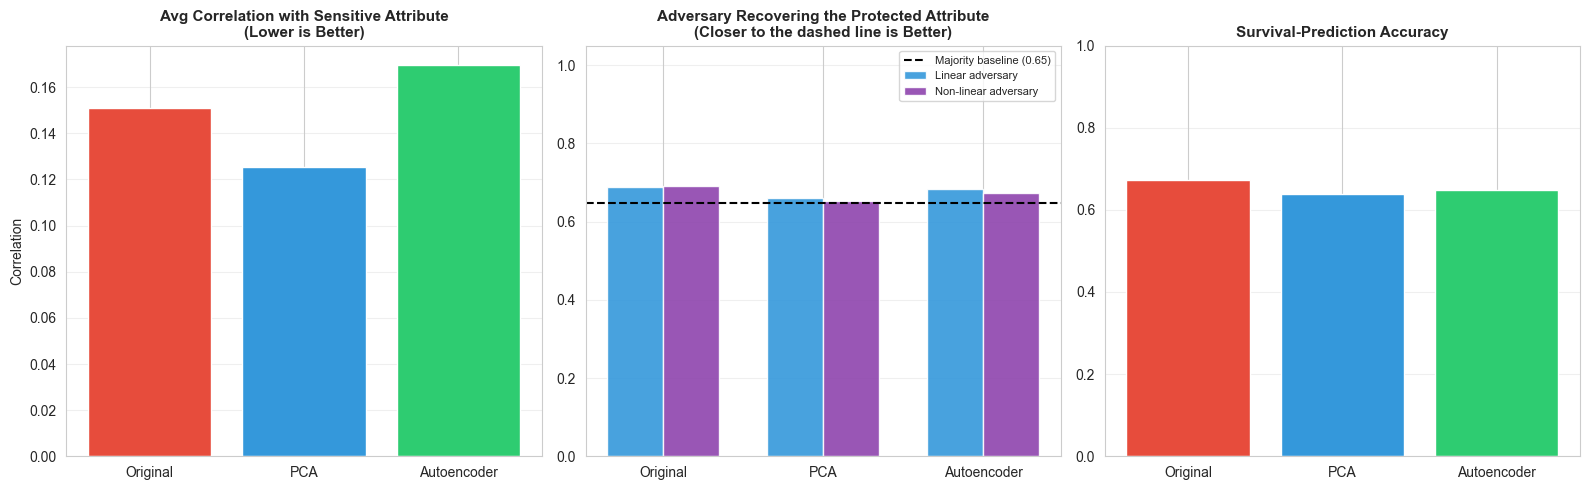

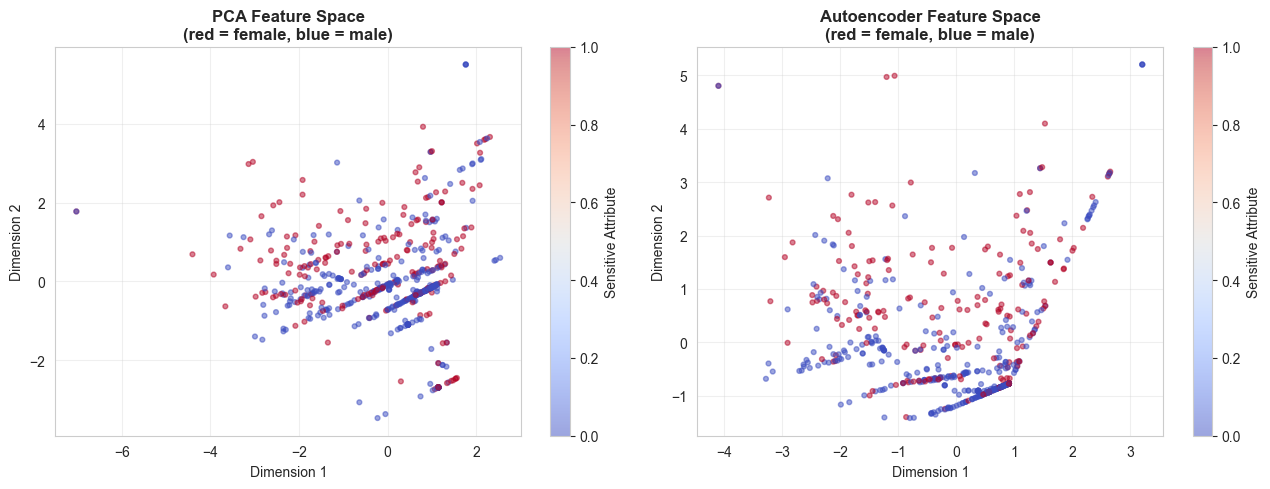

WHAT ACTUALLY HAPPENED (numbers computed from this run):

1. On the ORIGINAL features - with sex already removed from the columns -
   a non-linear adversary still recovered sex 69.2% of the time,
   against a 64.8% majority baseline. The 'innocent' features
   (fare, class, family size) carry the group between them.

2. Least leaky representation here: PCA (non-linear adversary 0.652).
   Its task accuracy vs the original features: -0.0336.

3. Compare the two adversary columns in the table. Wherever the
   non-linear adversary beats the linear one, the group is hiding in a
   NON-LINEAR pattern - the exact failure mode Notebook 02 demonstrated.

4. THE HONEST CONCLUSION: general-purpose compression (PCA, a plain
   autoencoder) is not a fairness technique. It was never asked to remove
   the group, so it mostly does not. If you need a fair representation,
   use a method that optimises against an adversary - and then TEST it
   with an adversary at least as strong as the one an attac

In [5]:
# Why visualize: bars compare leakage vs accuracy; the scatter plots let you SEE
# whether the two groups are still separable in each learned feature space.

# Step 5: Visualize the comparison

methods = list(results.keys())
colors = ['#e74c3c', '#3498db', '#2ecc71']
correlations = [results[m]['correlation'] for m in methods]
accuracies = [results[m]['accuracy'] for m in methods]
adversaries = [results[m]['adversary'] for m in methods]
adversaries_nl = [results[m]['adversary_nl'] for m in methods]

# Three panels: residual correlation, adversary accuracy (vs the majority
# baseline, NOT 0.5 - the groups are not evenly sized), task accuracy.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].bar(methods, correlations, color=colors)
axes[0].set_title('Avg Correlation with Sensitive Attribute\n(Lower is Better)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Correlation')

x = np.arange(len(methods)); width = 0.35
axes[1].bar(x - width/2, adversaries, width, label='Linear adversary',
            color='#3498db', alpha=0.9)
axes[1].bar(x + width/2, adversaries_nl, width, label='Non-linear adversary',
            color='#8e44ad', alpha=0.9)
axes[1].axhline(MAJORITY_BASELINE, color='black', linestyle='--',
                label=f'Majority baseline ({MAJORITY_BASELINE:.2f})')
axes[1].set_xticks(x); axes[1].set_xticklabels(methods)
axes[1].set_title('Adversary Recovering the Protected Attribute\n'
                  '(Closer to the dashed line is Better)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylim([0, 1.05]); axes[1].legend(fontsize=8)

axes[2].bar(methods, accuracies, color=colors)
axes[2].set_title('Survival-Prediction Accuracy', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1])
for ax in axes:
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Feature spaces colored by sensitive attribute
# Scatter each 2-D representation colored by group: well-mixed colors = group
# membership is no longer recoverable from the representation.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, name in zip(axes, ['PCA', 'Autoencoder']):
    feats = results[name]['features']
    sc = ax.scatter(feats[:, 0], feats[:, 1], c=sensitive_train,
                    cmap='coolwarm', alpha=0.5, s=12)
    ax.set_title(f'{name} Feature Space\n(red = female, blue = male)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimension 1'); ax.set_ylabel('Dimension 2')
    ax.grid(alpha=0.3)
    plt.colorbar(sc, ax=ax, label='Sensitive Attribute')
plt.tight_layout()
plt.show()

# Data-driven reading of the charts (computed, not assumed):
print("WHAT ACTUALLY HAPPENED (numbers computed from this run):")
orig_leak = results['Original']['adversary_nl']
print(f"\n1. On the ORIGINAL features - with sex already removed from the columns -")
print(f"   a non-linear adversary still recovered sex {orig_leak:.1%} of the time,")
print(f"   against a {MAJORITY_BASELINE:.1%} majority baseline. The 'innocent' features")
print(f"   (fare, class, family size) carry the group between them.")

best_hidden = min(results, key=lambda m: abs(results[m]['adversary_nl'] - MAJORITY_BASELINE))
print(f"\n2. Least leaky representation here: {best_hidden} "
      f"(non-linear adversary {results[best_hidden]['adversary_nl']:.3f}).")
acc_cost = results[best_hidden]['accuracy'] - results['Original']['accuracy']
print(f"   Its task accuracy vs the original features: {acc_cost:+.4f}.")

print(f"\n3. Compare the two adversary columns in the table. Wherever the")
print(f"   non-linear adversary beats the linear one, the group is hiding in a")
print(f"   NON-LINEAR pattern - the exact failure mode Notebook 02 demonstrated.")
print(f"\n4. THE HONEST CONCLUSION: general-purpose compression (PCA, a plain")
print(f"   autoencoder) is not a fairness technique. It was never asked to remove")
print(f"   the group, so it mostly does not. If you need a fair representation,")
print(f"   use a method that optimises against an adversary - and then TEST it")
print(f"   with an adversary at least as strong as the one an attacker would use.")

## 💬 Discuss

Argue from the table your own run produced. The adversary must beat the majority baseline of
**0.648** to have learned anything at all:

| Representation | Avg abs corr | Task acc | Adversary (linear) | Adversary (RF) |
|---|---|---|---|---|
| Original | 0.151 | 0.672 | 0.689 | 0.692 |
| PCA | **0.125** | 0.638 | 0.661 | 0.652 |
| Autoencoder | 0.170 | 0.649 | 0.684 | 0.674 |

1. **PCA has the lowest correlation and is not the fairest.** It reduced average correlation
   to 0.125 while dropping task accuracy by 3.4 points, and the adversary still beat the
   baseline. Two people read this table: one says "PCA reduced leakage, ship it", the other
   says "PCA bought a rounding error in leakage for a real loss in accuracy, and the group is
   still recoverable — this is not a mitigation". Both are reading the same numbers. Which
   reading would you defend in front of the person the model rejects, and what number would
   change your mind?
2. **How strong must the attacker be?** You ran a linear adversary and a random forest.
   A determined party — a rival, a journalist, a regulator, a jailbroken model — is not
   limited to scikit-learn defaults. What adversary strength should a *standard* require
   before a representation may be called fair, and who pays for running it? Note that
   "as strong as possible" is not implementable: say what you would actually write in a
   policy.
3. **What if the representation succeeded?** Suppose a targeted method drove the adversary
   to exactly 0.648 — no leakage at all. You now have a model that provably cannot tell men
   from women, and therefore provably cannot be audited for sex disparity by anyone,
   including a regulator. Is that a fair system or an unauditable one? (Compare the
   opposite design, Notebook 02's `ThresholdOptimizer`, which uses sex openly at decision
   time in order to equalise outcomes.)


## ⚠️ Where this breaks

- **PCA and plain autoencoders are not fairness methods, and this notebook proves it.**
  Their objective is variance or reconstruction; neither contains a fairness term, so
  neither has any reason to discard group information. Your run confirms it — the
  autoencoder's average correlation (**0.170**) came out *higher* than the original
  features' (**0.151**). If a vendor lists "dimensionality reduction" under bias mitigation,
  this table is your reply.
- **Absence of evidence from a weak attacker is not evidence of absence.** The whole method
  rests on the adversary. A representation is only as clean as the strongest attacker you
  bothered to run, and you can never run the strongest one. Report the adversary you used,
  its accuracy, and the majority baseline — always all three.
- **Success on the audited attribute says nothing about the others.** Suppose you scrub sex
  perfectly. Age, disability, nationality and postcode are all still in there, and each one
  needs its own adversary. Fair representation is per-attribute work, and the attribute you
  did not think of is the one you will be asked about.
- **The transformed features are unreadable, so recourse dies.** After PCA, the honest
  explanation of a rejection is "component 3 was too low", which is not something a person
  can act on and is not an "accurate statement of specific reasons" under, for example, US
  adverse-action rules (Unit 4, Notebook 03). Fairness bought here is paid for in
  transparency there.
- **You cannot transform your way out of a missing group.** If a group is barely present in
  the data, no feature transformation can conjure the missing evidence — as the section
  below says. That is a **collection** problem, and Notebook 05 measures what it costs.

**The cheaper alternative:** in most production settings, fix the sample and the label
first (Notebook 05, and Obermeyer's relabelling from Notebook 01), then apply a *targeted*
method — adversarial debiasing or `CorrelationRemover` — and test it with the strongest
adversary you can afford. Untargeted compression is the one option this notebook can tell
you to skip.


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We knew how to detect and mitigate bias, but features may still encode sensitive information.

**AFTER this notebook**: We can:
- ✅ **Measure** which real features act as proxies for a protected attribute
- ✅ Use PCA to build compressed representations - and *measure* how much sensitive-attribute correlation survives
- ✅ Use autoencoders for feature transformation
- ✅ Use an adversary as a leakage detector, at two different strengths
- ✅ Compare fair-representation methods on leakage *and* task accuracy
- ✅ Score an adversary against the **majority baseline**, not against 0.5

### Key Takeaways

1. **Real proxies are weak individually and strong together**: no single Titanic
   feature correlated strongly with sex, yet a non-linear adversary still beat the
   majority baseline using the features together. Audit the *combined* leak.
2. **PCA is not a fairness technique**: it compresses whatever variance is largest.
   In our run it reduced leakage slightly and cost task accuracy - because it was
   never asked to remove the group in the first place.
3. **Autoencoders behave the same way**: a plain reconstruction objective has no
   fairness term, so there is no reason for it to discard group information.
4. **Adversarial debiasing** is the family that actually targets the leak - and even
   then, test it with an attacker at least as strong as a real one.
5. **Trade-offs**: read the leakage column and the accuracy column together. A
   representation that hides the group by destroying all signal is not a success.
6. **Compare against the right baseline**: the Titanic groups are ~65/35, so an
   adversary scoring 0.65 has learned nothing at all.

---

## 🚫 When Fair Representation Hits a Limitation

### The Limitation We Discovered

We've learned how to ensure fair representation using PCA, autoencoders, and adversarial techniques. **But there's still a challenge:**

**How do we apply all these techniques to build fair AI systems from the start?**

Fair representation techniques work well when:
- ✅ We have data to transform
- ✅ We can apply feature-level techniques
- ✅ We understand the bias in our data

**But building fair AI systems requires:**
- ❌ **Systematic approach** from data collection to deployment
- ❌ **Best practices** for fair AI development
- ❌ **Integration** of all techniques we've learned
- ❌ **Real-world application** of fairness principles

There is also a limitation this notebook could not solve at all: if a group is
barely present in the data to begin with, no feature transformation can conjure
the missing evidence. That is a **collection** problem, not a modelling one.

### Why This Is a Problem

When we have techniques but no systematic approach:
- We may miss important fairness considerations
- We may not apply techniques consistently
- We may not build fairness into the development process
- We may create systems that are fair in some ways but not others

### The Solution: Fair AI Development

We need **systematic fair AI development practices** to:
1. Integrate all fairness techniques we've learned
2. Build fairness into the entire development lifecycle
3. Apply best practices consistently
4. Create truly fair AI systems from the start

**This is exactly what we'll learn in the next notebook: Fair AI Development!**

---

## ➡️ Next Steps

**You've completed this notebook!** Now you understand:
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ How to measure what a representation still leaks (This notebook!)
- ✅ **The limitation**: We need systematic development practices!

**Next notebook**: `05_fair_ai_development.ipynb`
- Learn systematic approaches to fair AI development
- Integrate all fairness techniques
- Build fair AI systems from the start

**Congratulations!** 🎉 You've learned how to measure and reduce what your features leak!

## 📚 References

1. Zemel, R., Wu, Y., Swersky, K., Pitassi, T. & Dwork, C. (2013). *Learning Fair Representations*. ICML 2013, PMLR 28. <https://proceedings.mlr.press/v28/zemel13.html>
2. Dwork, C., Hardt, M., Pitassi, T., Reingold, O. & Zemel, R. (2012). *Fairness Through Awareness*. ITCS 2012. <https://arxiv.org/abs/1104.3913>
3. Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K. & Galstyan, A. (2021). *A Survey on Bias and Fairness in Machine Learning*. ACM Computing Surveys, 54(6). <https://arxiv.org/abs/1908.09635>